# Day 49 — Batch Normalization, Transfer Learning
- Understand Batch Normalization.
- Compare training and inference behavior.
- Use gradient clipping with `clipvalue` and `clipnorm`.
- Reuse pretrained layers with transfer learning.
- Freeze layers and fine-tune a pretrained model.
- Understand unsupervised pretraining and auxiliary tasks.


## 1.2 Model with Batch Normalization

In [43]:
model_bn = keras.Sequential([
    keras.layers.Input(shape=(28, 28)),
    keras.layers.Flatten(),
    keras.layers.Dense(300),
    keras.layers.BatchNormalization(),
    keras.layers.Activation("relu"),
    keras.layers.Dense(100),
    keras.layers.BatchNormalization(),
    keras.layers.Activation("relu"),
    keras.layers.Dense(10, activation="softmax")
])

model_bn.compile(
    optimizer=keras.optimizers.SGD(learning_rate=0.01),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_bn = model_bn.fit(
    X_train_small,
    y_train_small,
    validation_split=0.1,
    epochs=10,
    batch_size=64
)


Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8198 - loss: 0.6934 - val_accuracy: 0.8937 - val_loss: 0.4243
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9149 - loss: 0.3391 - val_accuracy: 0.9167 - val_loss: 0.2995
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9338 - loss: 0.2600 - val_accuracy: 0.9297 - val_loss: 0.2492
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9453 - loss: 0.2150 - val_accuracy: 0.9393 - val_loss: 0.2181
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9541 - loss: 0.1839 - val_accuracy: 0.9417 - val_loss: 0.1969
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9611 - loss: 0.1601 - val_accuracy: 0.9453 - val_loss: 0.1811
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9663 - loss: 0.1411 - val_accuracy: 0.9490 - val_loss: 0.1689
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9715 - loss: 0.1252 - val_accuracy: 0.

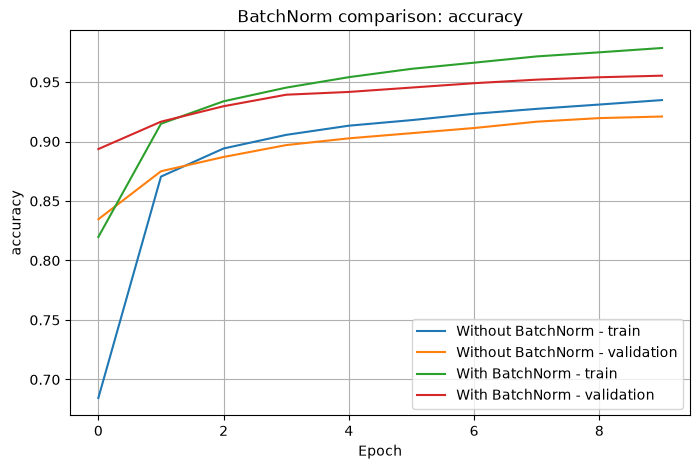

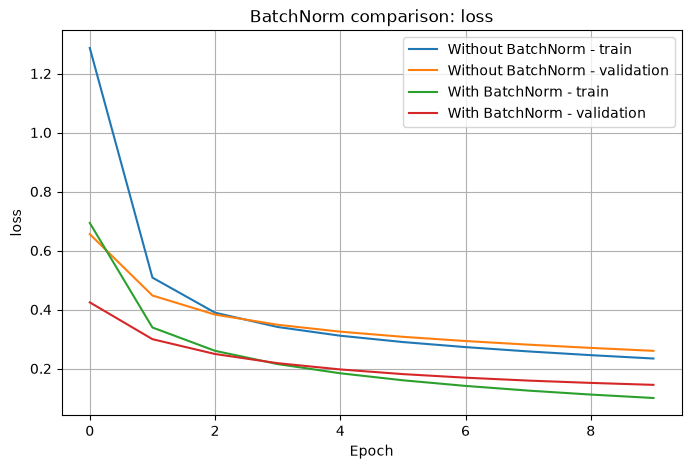

In [44]:
def plot_metric(history_a, history_b, metric):
    plt.figure(figsize=(8, 5))
    plt.plot(history_a.history[metric], label=f"Without BatchNorm - train")
    plt.plot(history_a.history[f"val_{metric}"], label=f"Without BatchNorm - validation")
    plt.plot(history_b.history[metric], label=f"With BatchNorm - train")
    plt.plot(history_b.history[f"val_{metric}"], label=f"With BatchNorm - validation")
    plt.xlabel("Epoch")
    plt.ylabel(metric)
    plt.title(f"BatchNorm comparison: {metric}")
    plt.grid(True)
    plt.legend()
    plt.show()

plot_metric(history_no_bn, history_bn, "accuracy")
plot_metric(history_no_bn, history_bn, "loss")


## 1.3 Inspect BatchNorm parameters

In [45]:
bn_layers = [
    layer for layer in model_bn.layers
    if isinstance(layer, keras.layers.BatchNormalization)
]

for index, layer in enumerate(bn_layers, start=1):
    print(f"BatchNorm layer {index}")
    print("Trainable weights:")
    for weight in layer.trainable_weights:
        print(" ", weight.name, weight.shape)

    print("Non-trainable weights:")
    for weight in layer.non_trainable_weights:
        print(" ", weight.name, weight.shape)
    print()


BatchNorm layer 1
Trainable weights:
  gamma (300,)
  beta (300,)
Non-trainable weights:
  moving_mean (300,)
  moving_variance (300,)

BatchNorm layer 2
Trainable weights:
  gamma (100,)
  beta (100,)
Non-trainable weights:
  moving_mean (100,)
  moving_variance (100,)



### Training vs inference

- During training, BatchNorm uses the current mini-batch mean and variance.
- During inference, it uses moving averages accumulated during training.

This difference matters in custom training loops and subclassed models.


# 2. Gradient Clipping

Exploding gradients can produce extremely large parameter updates. Gradient clipping limits gradients before the optimizer applies them.

- `clipvalue`: clips individual gradient components.
- `clipnorm`: limits the overall gradient norm.


In [46]:
model_clip_value = keras.Sequential([
    keras.layers.Input(shape=(28, 28)),
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dense(10, activation="softmax")
])

model_clip_value.compile(
    optimizer=keras.optimizers.SGD(
        learning_rate=0.01,
        clipvalue=1.0
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model_clip_norm = keras.Sequential([
    keras.layers.Input(shape=(28, 28)),
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dense(10, activation="softmax")
])

model_clip_norm.compile(
    optimizer=keras.optimizers.SGD(
        learning_rate=0.01,
        clipnorm=1.0
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("clipvalue optimizer:", model_clip_value.optimizer)
print("clipnorm optimizer:", model_clip_norm.optimizer)


clipvalue optimizer: <keras.src.optimizers.sgd.SGD object at 0x000001C2C3DD2250>
clipnorm optimizer: <keras.src.optimizers.sgd.SGD object at 0x000001C2C3DE7050>


| Setting | Meaning |
|---|---|
| `clipvalue=1.0` | Clips each individual gradient value |
| `clipnorm=1.0` | Limits the overall gradient norm |

Gradient clipping is a stabilization technique. It does not replace a sensible learning rate or architecture.


# 3. Transfer Learning

Transfer learning reuses representations learned by a pretrained model.

Typical workflow:

```text
Pretrained model
      ↓
Freeze pretrained layers
      ↓
Add a task-specific head
      ↓
Train the new head
      ↓
Unfreeze selected layers
      ↓
Fine-tune with a small learning rate
```


## 3.1 Load MobileNetV2

The first run may download ImageNet weights if they are not already cached.


In [47]:
base_model = keras.applications.MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(96, 96, 3)
)

base_model.trainable = False

print("Base model layers:", len(base_model.layers))
print("Base model trainable:", base_model.trainable)


Base model layers: 154
Base model trainable: False


## 3.2 Build the transfer-learning model

In [48]:
transfer_model = keras.Sequential([
    keras.layers.Input(shape=(96, 96, 3)),
    base_model,
    keras.layers.GlobalAveragePooling2D(),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(10, activation="softmax")
])

transfer_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

transfer_model.summary()


Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,270,794 (8.66 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 3.3 Prepare CIFAR-10

We use a subset to keep the notebook manageable. Images are resized to the MobileNetV2 input size and preprocessed using the model's preprocessing function.


In [49]:
import numpy as np, tensorflow as tf
n_train, n_test = 500, 200
x_train = np.random.randint(0,256,(n_train,32,32,3),dtype=np.uint8)
y_train = np.random.randint(0,10,(n_train,),dtype=np.uint8)
x_test  = np.random.randint(0,256,(n_test,32,32,3),dtype=np.uint8)
y_test  = np.random.randint(0,10,(n_test,),dtype=np.uint8)

# resize + preprocess (optional)
x_train = tf.image.resize(x_train, (96,96)).numpy()
x_test  = tf.image.resize(x_test,  (96,96)).numpy()
x_train = tf.keras.applications.mobilenet_v2.preprocess_input(x_train)
x_test  = tf.keras.applications.mobilenet_v2.preprocess_input(x_test)

train_ds = tf.data.Dataset.from_tensor_slices((x_train, y_train)).shuffle(500).batch(64).prefetch(tf.data.AUTOTUNE)
test_ds  = tf.data.Dataset.from_tensor_slices((x_test,  y_test)).batch(64).prefetch(tf.data.AUTOTUNE)

## 3.4 Train the new head

The pretrained base remains frozen while the new classification head is trained.


In [50]:
base_model.trainable = False

transfer_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_transfer = transfer_model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=3
)

test_loss, test_accuracy = transfer_model.evaluate(test_ds, verbose=0)

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")


Epoch 1/3
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 193ms/step - accuracy: 0.1160 - loss: 3.1229 - val_accuracy: 0.0950 - val_loss: 2.5311
Epoch 2/3
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step - accuracy: 0.0840 - loss: 2.8272 - val_accuracy: 0.1000 - val_loss: 2.4326
Epoch 3/3
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step - accuracy: 0.1040 - loss: 2.7240 - val_accuracy: 0.1000 - val_loss: 2.3514
Test loss: 2.3514
Test accuracy: 0.1000


# 4. Fine-Tuning

Fine-tuning adapts selected pretrained layers to the new task.

Use a small learning rate to reduce the risk of destroying useful pretrained representations. BatchNorm layers are commonly kept frozen when the new dataset is small.


In [51]:
# Unfreeze only the last 30 base-model layers.
base_model.trainable = True
fine_tune_from = max(0, len(base_model.layers) - 30)

for index, layer in enumerate(base_model.layers):
    if index < fine_tune_from:
        layer.trainable = False
    elif isinstance(layer, keras.layers.BatchNormalization):
        layer.trainable = False
    else:
        layer.trainable = True

transfer_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

trainable_base_layers = [
    layer.name for layer in base_model.layers if layer.trainable
]

print("Trainable base layers:", len(trainable_base_layers))
print(trainable_base_layers)


Trainable base layers: 19
['block_14_expand', 'block_14_expand_relu', 'block_14_depthwise', 'block_14_depthwise_relu', 'block_14_project', 'block_14_add', 'block_15_expand', 'block_15_expand_relu', 'block_15_depthwise', 'block_15_depthwise_relu', 'block_15_project', 'block_15_add', 'block_16_expand', 'block_16_expand_relu', 'block_16_depthwise', 'block_16_depthwise_relu', 'block_16_project', 'Conv_1', 'out_relu']


In [52]:
fine_tune_history = transfer_model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=2
)

fine_tune_loss, fine_tune_accuracy = transfer_model.evaluate(
    test_ds,
    verbose=0
)

print(f"Fine-tuned test loss: {fine_tune_loss:.4f}")
print(f"Fine-tuned test accuracy: {fine_tune_accuracy:.4f}")


Epoch 1/2
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 205ms/step - accuracy: 0.0940 - loss: 2.6110 - val_accuracy: 0.0800 - val_loss: 2.3573
Epoch 2/2
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step - accuracy: 0.0900 - loss: 2.4661 - val_accuracy: 0.1150 - val_loss: 2.3058
Fine-tuned test loss: 2.3058
Fine-tuned test accuracy: 0.1150


# 5. Unsupervised Pretraining

Conceptual workflow:

```text
Large unlabeled dataset
          ↓
Representation learning
          ↓
Pretrained network
          ↓
Small labeled dataset
          ↓
Supervised fine-tuning
```

The goal is to learn useful representations from unlabeled data before supervised training.


# 6. Auxiliary Tasks

An auxiliary task is an additional related prediction task trained alongside the main task.

```text
                 Shared representation
                    /           \
                   /             \
             Main task       Auxiliary task
                 ↓                 ↓
             prediction        prediction
```

The additional task provides another learning signal and may encourage useful internal representations.


# Quick Summary

- **BatchNorm:** stabilizes activations and optimization.
- **Gradient clipping:** controls excessively large gradients.
- **Transfer learning:** reuses knowledge from a pretrained model.
- **Freezing:** keeps pretrained weights unchanged.
- **Fine-tuning:** adapts selected pretrained layers with a small learning rate.
- **Unsupervised pretraining:** learns representations from unlabeled data.
- **Auxiliary tasks:** provide an additional related learning signal.
